In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("train.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# 1. HEANDLING MISSING VALUES

In [3]:
cat_df = df.select_dtypes(include = object)
num_df = df.select_dtypes(include = ["int64", "float64"])

In [4]:
num_df.isnull().sum()

Id                 0
MSSubClass         0
LotFrontage      259
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
MasVnrArea         8
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageYrBlt       81
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64

In [5]:
# heandling numerical missing value

df[['GarageYrBlt', 'MasVnrArea']] = df[['GarageYrBlt', 'MasVnrArea']].fillna(0)
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

In [6]:
cat_df.isnull().sum()

MSZoning            0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinType2       38
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
KitchenQual         0
Functional          0
FireplaceQu       690
GarageType         81
GarageFinish       81
GarageQual         81
GarageCond         81
PavedDrive          0
PoolQC           1453
Fence            1179
MiscFeature      1406
SaleType            0
SaleCondition       0
dtype: int64

In [7]:
# heandling catagorecal missing value 

non_col = [
    'PoolQC', 'Fence', 'MiscFeature', 'Alley',
    'FireplaceQu', 'MasVnrType'
]

df[non_col] = df[non_col].fillna("None")

garg_col = [
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'
]

df[garg_col] = df[garg_col].fillna("None")

Bsmt_col = [
    'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2'
]

df[Bsmt_col] = df[Bsmt_col].fillna("None")

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [8]:
# chacking  value
print(df.isnull().sum().to_string())

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
Alley            0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr

# 2. Feature Engineering

In [9]:
df['LuxuryScore'] = df['OverallQual'] + df['OverallCond']
df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)
df['TotalRooms'] = df['TotRmsAbvGrd'] + df['BedroomAbvGr']

# 3. Encoding

In [10]:
# Label encoding

qual_map = {
    "Ex" : 5,
    "Gd" : 4,
    "TA" : 3,
    "Fa" : 2,
    "Po" : 1,
    "None" : 0,
    "NA" : 0
}

qual_cols = [
    'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond',
    'HeatingQC',
    'KitchenQual',
    'FireplaceQu',
    'GarageQual', 'GarageCond',
    'PoolQC'   
]

for col in qual_cols :
    df[col] = df[col].map(qual_map)


bsmt_type_map = {
    'GLQ': 6,
    'ALQ': 5,
    'BLQ': 4,
    'Rec': 3,
    'LwQ': 2,
    'Unf': 1,
    'None': 0,
    'NA' : 0
}

bsmt_type_col = ['BsmtFinType1', 'BsmtFinType2']

for col in bsmt_type_col :
    df[col] = df[col].map(bsmt_type_map)



bsmt_exp_map = {
    'Gd': 4,
    'Av': 3,
    'Mn': 2,
    'No': 1,
    'None': 0,
    'NA' : 0
}

df['BsmtExposure'] = df['BsmtExposure'].map(bsmt_exp_map)


garage_finish_map = {
    'Fin': 3,
    'RFn': 2,
    'Unf': 1,
    'None': 0,
    'NA' : 0
}

df['GarageFinish'] = df['GarageFinish'].map(garage_finish_map)

In [11]:
#  one-hot encoding

df['MSSubClass'] = df['MSSubClass'].astype(str)

ordinal_cols = [
    'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual',
    'FireplaceQu',
    'GarageQual', 'GarageCond',
    'PoolQC',
    'BsmtFinType1', 'BsmtFinType2',
    'BsmtExposure',
    'GarageFinish'
]

cat_cols = df.select_dtypes(include=['object']).columns

nominal_cols = [col for col in cat_cols if col not in ordinal_cols]

df = pd.get_dummies(df, columns = nominal_cols, drop_first = True) 

In [12]:
df = df.astype(int)

# 4. Skewness in Data

In [13]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

skewness = num_cols.skew()

skewed_cols = skewness[abs(skewness) > 0.75].index

print(skewed_cols)

final_cols = [
    col for col in skewed_cols 
    if df[col].nunique() > 10 and col != 'Id'
]

for col in final_cols:
    df[col] = np.log1p(df[col])

Index(['LotFrontage', 'LotArea', 'MasVnrArea', 'ExterQual', 'ExterCond',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinSF1', 'BsmtFinType2',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=200)


# 5. Model Training

In [14]:
X = df.drop("SalePrice", axis = 1)
y = df["SalePrice"]

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#    LinearRegression Model

In [16]:
from sklearn.linear_model import LinearRegression

LR_model = LinearRegression()
LR_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
y_pred = LR_model.predict(X_test)

In [18]:
from sklearn.metrics import root_mean_squared_error

LR_RMSE_value = root_mean_squared_error(y_test, y_pred)
print(LR_RMSE_value)

0.16343432971144448


# DecisionTreeRegressor Model

In [19]:
from sklearn.tree import DecisionTreeRegressor

dec_tree_reg_model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5
)

dec_tree_reg_model.fit(X_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [20]:
y_pred = dec_tree_reg_model.predict(X_test)

In [21]:
from sklearn.metrics import root_mean_squared_error

dec_tree_reg_RMSE_value = root_mean_squared_error(y_test, y_pred)
print(dec_tree_reg_RMSE_value)

0.1987888701176213


# XGBoost Regressor model

In [22]:
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping


xgb_reg_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,   # L1 regularization
    reg_lambda=1,    # L2 regularization
    random_state=42
)


xgb_reg_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

[0]	validation_0-rmse:0.41748
[1]	validation_0-rmse:0.40254
[2]	validation_0-rmse:0.38884
[3]	validation_0-rmse:0.37470
[4]	validation_0-rmse:0.36176
[5]	validation_0-rmse:0.34969
[6]	validation_0-rmse:0.33873
[7]	validation_0-rmse:0.32764
[8]	validation_0-rmse:0.31720
[9]	validation_0-rmse:0.30756
[10]	validation_0-rmse:0.29858
[11]	validation_0-rmse:0.29025
[12]	validation_0-rmse:0.28195
[13]	validation_0-rmse:0.27428
[14]	validation_0-rmse:0.26648
[15]	validation_0-rmse:0.25957
[16]	validation_0-rmse:0.25281
[17]	validation_0-rmse:0.24627
[18]	validation_0-rmse:0.24032
[19]	validation_0-rmse:0.23475
[20]	validation_0-rmse:0.22938
[21]	validation_0-rmse:0.22443
[22]	validation_0-rmse:0.21987
[23]	validation_0-rmse:0.21528
[24]	validation_0-rmse:0.21163
[25]	validation_0-rmse:0.20772
[26]	validation_0-rmse:0.20453
[27]	validation_0-rmse:0.20095
[28]	validation_0-rmse:0.19752
[29]	validation_0-rmse:0.19433
[30]	validation_0-rmse:0.19181
[31]	validation_0-rmse:0.18938
[32]	validation_0-

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [23]:
y_pred = xgb_reg_model.predict(X_test)

In [24]:
from sklearn.metrics import root_mean_squared_error

xgb_reg_RMSE_value = root_mean_squared_error(y_test, y_pred)
print(xgb_reg_RMSE_value)

0.13984905815393178


In [25]:
data = {
    "Model": ["Linear Regression", "DecisionTreeRegressor", "XGBoost"],
    "RMSE": [0.16343, 0.19878, 0.13984]
}

df = pd.DataFrame(data)
df

,Model,RMSE
0,Linear Regression,0.16343
1,DecisionTreeRegressor,0.19878
2,XGBoost,0.13984


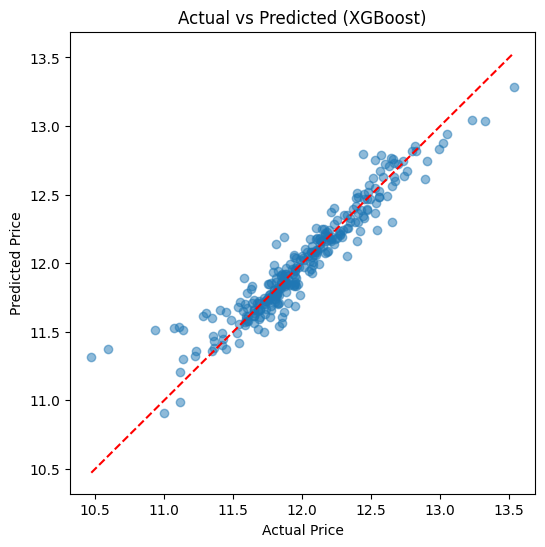

In [28]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (XGBoost)")
plt.savefig("XGBoost_model_graph.png") 
plt.show()